# Step 4: Exploratory data analysis

Explore platform delivery performance, delay patterns, ratings, refunds, product categories, and order value using the cleaned dataset. Save report-ready charts in `../visuals/`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:

df = pd.read_csv("../data/cleaned/orders_cleaned.csv", parse_dates=["Order Date & Time"])

df["Late"] = (df["Delayed"] == "Yes").astype(int)
df["Refund"] = (df["Refund Requested"]=="Yes").astype(int)
print(df.shape) 


(99936, 22)


In [3]:
df

,Order ID,Customer ID,Platform,City,Order Date & Time,Product Category,Order Value (INR),Payment Method,Delivery Distance (km),Promised SLA (Minutes),...,Delayed,Service Rating,Customer Feedback,Refund Requested,Order Date,Hour,Weekday,Is Weekend,Late,Refund
0,ORD021896,CUST6682,Swiggy Instamart,Bengaluru,2025-01-01 00:09:59,Grocery,317,UPI,3.7,20,...,No,NaN,No Comments,No,2025-01-01,0,Wednesday,False,0,0
1,ORD057626,CUST1456,Blinkit,Hyderabad,2025-01-01 00:16:48,Grocery,462,Card,1.0,15,...,No,5.0,"Easy to order, loved it!",No,2025-01-01,0,Wednesday,False,0,0
2,ORD084414,CUST5717,Blinkit,Mumbai,2025-01-01 00:32:08,Snacks,121,UPI,1.4,15,...,No,4.0,No Comments,No,2025-01-01,0,Wednesday,False,0,0
3,ORD072068,CUST1390,Swiggy Instamart,Mumbai,2025-01-01 00:37:52,Beverages,174,UPI,2.1,20,...,No,4.0,No Comments,No,2025-01-01,0,Wednesday,False,0,0
4,ORD023102,CUST1084,Swiggy Instamart,Bengaluru,2025-01-01 00:38:10,Personal Care,213,UPI,1.8,20,...,No,5.0,No Comments,No,2025-01-01,0,Wednesday,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99931,ORD073090,CUST4072,Blinkit,Pune,2025-03-31 23:47:43,Personal Care,1281,UPI,1.0,15,...,Yes,3.0,Delivery was fine,No,2025-03-31,23,Monday,False,1,0
99932,ORD081724,CUST3836,Blinkit,Chennai,2025-03-31 23:49:38,Personal Care,290,Wallet,1.1,15,...,No,5.0,No Comments,No,2025-03-31,23,Monday,False,0,0
99933,ORD006432,CUST1901,Blinkit,Hyderabad,2025-03-31 23:49:55,Dairy,225,Card,1.5,15,...,No,4.0,No Comments,No,2025-03-31,23,Monday,False,0,0
99934,ORD043788,CUST8039,Blinkit,Bengaluru,2025-03-31 23:55:33,Grocery,784,UPI,1.5,15,...,No,5.0,No Comments,No,2025-03-31,23,Monday,False,0,0


In [4]:
# Cell 2: overall baseline
print("Total orders : ",len(df))
print("Late rate (%):", round(df["Late"].mean() * 100, 1))
print("Avg delivery time (min):", round(df["Delivery Time (Minutes)"].mean(), 1))
print("Avg rating (rated orders only):", round(df["Service Rating"].mean(), 2))
print("Refund rate (%):", round(df["Refund"].mean() * 100, 1))

Total orders :  99936
Late rate (%): 16.5
Avg delivery time (min): 15.9
Avg rating (rated orders only): 4.25
Refund rate (%): 4.8


In [5]:
platfrom = df.groupby("Platform").agg(
   orders=("Order ID", "count"),
    avg_time=("Delivery Time (Minutes)", "mean"),
    late_rate=("Late", "mean"),
    refund_rate=("Refund", "mean"),
    avg_rating=("Service Rating", "mean") 
)
platfrom[["late_rate","refund_rate"]]*=100
platfrom.round(2)

,orders,avg_time,late_rate,refund_rate,avg_rating
Platform,,,,,
Blinkit,44788,12.99,21.70,4.70,4.25
JioMart,19906,22.16,7.99,4.84,4.28
Swiggy Instamart,35242,16.09,14.83,4.78,4.25


In [6]:
city = df.groupby("City").agg(
    orders=("Order ID", "count"),
    avg_time=("Delivery Time (Minutes)", "mean"),
    late_rate=("Late", "mean"),
)
city["late_rate"]*=100
city.sort_values("late_rate",ascending=False).round(2)

,orders,avg_time,late_rate
City,,,
Bengaluru,21526,17.23,22.78
Mumbai,23823,16.71,20.29
Unknown,1496,15.78,16.24
Delhi,23642,15.67,14.75
Chennai,8889,14.60,10.99
Hyderabad,11724,14.68,10.91
Pune,8836,14.15,9.20


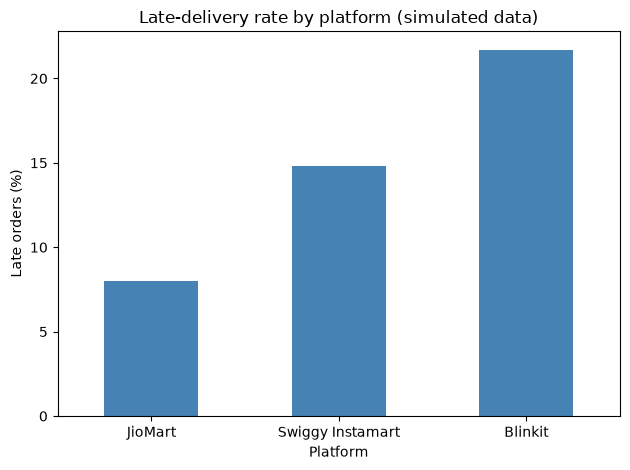

In [7]:
platfrom["late_rate"].sort_values().plot(kind="bar", color="steelblue")
plt.title("Late-delivery rate by platform (simulated data)")
plt.ylabel("Late orders (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../visuals/late_rate_by_platform.png", dpi=150)
plt.show()

In [8]:
# platform × city late rates (the confounding check)

known = df[df["City"] != "Unknown"]
pivot = known.pivot_table(index="City", columns="Platform", values="Late", aggfunc="mean") * 100
pivot.round(1)


Platform,Blinkit,JioMart,Swiggy Instamart
City,,,
Bengaluru,30.3,10.6,20.2
Chennai,13.9,4.6,10.7
Delhi,19.1,7.6,13.3
Hyderabad,13.9,5.1,10.4
Mumbai,27.0,9.7,17.5
Pune,11.3,5.2,8.9


In [9]:
# late rate by hour
hourly = df.groupby("Hour").agg(
    orders=("Order ID", "count"),
    late_rate=("Late", "mean"),
    avg_time=("Delivery Time (Minutes)", "mean"),
)
hourly["late_rate"] *= 100
hourly.round(1)

,orders,late_rate,avg_time
Hour,,,
0,693,7.4,14.1
1,427,9.4,14.3
2,294,8.8,14.3
3,289,9.0,14.2
4,417,8.6,14.2
5,1187,9.4,14.0
6,2161,7.3,14.1
7,4256,7.8,14.0
8,5840,11.8,15.7


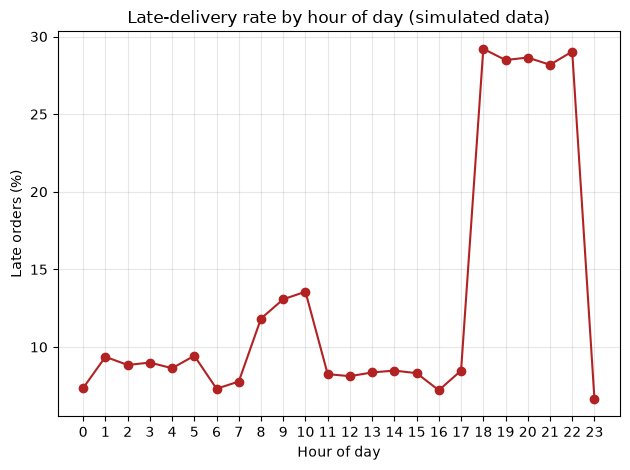

In [10]:
hourly["late_rate"].plot(kind="line", marker="o", color="firebrick")
plt.title("Late-delivery rate by hour of day (simulated data)")
plt.xlabel("Hour of day")
plt.ylabel("Late orders (%)")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../visuals/late_rate_by_hour.png", dpi=150)
plt.show()

In [11]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday = (df.groupby("Weekday")["Late"].mean() * 100).reindex(order)
weekday.round(1)

Weekday
Monday       13.9
Tuesday      14.4
Wednesday    13.8
Thursday     14.1
Friday       13.7
Saturday     21.5
Sunday       21.9
Name: Late, dtype: float64

In [12]:
df

,Order ID,Customer ID,Platform,City,Order Date & Time,Product Category,Order Value (INR),Payment Method,Delivery Distance (km),Promised SLA (Minutes),...,Delayed,Service Rating,Customer Feedback,Refund Requested,Order Date,Hour,Weekday,Is Weekend,Late,Refund
0,ORD021896,CUST6682,Swiggy Instamart,Bengaluru,2025-01-01 00:09:59,Grocery,317,UPI,3.7,20,...,No,NaN,No Comments,No,2025-01-01,0,Wednesday,False,0,0
1,ORD057626,CUST1456,Blinkit,Hyderabad,2025-01-01 00:16:48,Grocery,462,Card,1.0,15,...,No,5.0,"Easy to order, loved it!",No,2025-01-01,0,Wednesday,False,0,0
2,ORD084414,CUST5717,Blinkit,Mumbai,2025-01-01 00:32:08,Snacks,121,UPI,1.4,15,...,No,4.0,No Comments,No,2025-01-01,0,Wednesday,False,0,0
3,ORD072068,CUST1390,Swiggy Instamart,Mumbai,2025-01-01 00:37:52,Beverages,174,UPI,2.1,20,...,No,4.0,No Comments,No,2025-01-01,0,Wednesday,False,0,0
4,ORD023102,CUST1084,Swiggy Instamart,Bengaluru,2025-01-01 00:38:10,Personal Care,213,UPI,1.8,20,...,No,5.0,No Comments,No,2025-01-01,0,Wednesday,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99931,ORD073090,CUST4072,Blinkit,Pune,2025-03-31 23:47:43,Personal Care,1281,UPI,1.0,15,...,Yes,3.0,Delivery was fine,No,2025-03-31,23,Monday,False,1,0
99932,ORD081724,CUST3836,Blinkit,Chennai,2025-03-31 23:49:38,Personal Care,290,Wallet,1.1,15,...,No,5.0,No Comments,No,2025-03-31,23,Monday,False,0,0
99933,ORD006432,CUST1901,Blinkit,Hyderabad,2025-03-31 23:49:55,Dairy,225,Card,1.5,15,...,No,4.0,No Comments,No,2025-03-31,23,Monday,False,0,0
99934,ORD043788,CUST8039,Blinkit,Bengaluru,2025-03-31 23:55:33,Grocery,784,UPI,1.5,15,...,No,5.0,No Comments,No,2025-03-31,23,Monday,False,0,0


In [13]:
df["Distance Band"] = pd.cut(df["Delivery Distance (km)"], bins=[0, 1, 2, 3, 5, 10],
                             labels=["0-1 km", "1-2 km", "2-3 km", "3-5 km", "5+ km"])
dist = df.groupby("Distance Band", observed=True).agg(
    orders=("Order ID", "count"),
    late_rate=("Late", "mean"),
    avg_time=("Delivery Time (Minutes)", "mean"),
)
dist["late_rate"] *= 100
dist.round(1)

,orders,late_rate,avg_time
Distance Band,,,
0-1 km,26807,8.3,14.1
1-2 km,34037,12.1,15.3
2-3 km,20757,18.7,16.6
3-5 km,15176,30.2,18.3
5+ km,3159,54.3,21.3


In [14]:
df["Basket"] = pd.cut(df["Order Value (INR)"], bins=[0, 200, 500, 1000, 5000],
                      labels=["Under 200", "200-500", "500-1000", "Over 1000"])
basket = df.groupby("Basket", observed=True).agg(
    orders=("Order ID", "count"),
    late_rate=("Late", "mean"),
    avg_time=("Delivery Time (Minutes)", "mean"),
)
basket["late_rate"] *= 100
basket.round(1)

,orders,late_rate,avg_time
Basket,,,
Under 200,23780,16.1,15.8
200-500,52648,15.8,15.8
500-1000,19259,16.1,15.8
Over 1000,4249,30.9,18.3


In [15]:
late_only = df[df["Late"] == 1]
print(late_only.groupby("Platform")["Delivery Delay (Minutes)"].agg(["count", "mean", "median", "max"]).round(1))

                  count  mean  median  max
Platform                                  
Blinkit            9721   5.1     3.0   34
JioMart            1591   6.3     4.0   30
Swiggy Instamart   5225   5.7     4.0   34


In [20]:
df.head(1).T

,0
Order ID,ORD021896
Customer ID,CUST6682
Platform,Swiggy Instamart
City,Bengaluru
Order Date & Time,2025-01-01 00:09:59
Product Category,Grocery
Order Value (INR),317
Payment Method,UPI
Delivery Distance (km),3.7
Promised SLA (Minutes),20


In [ ]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday = (df.groupby("Weekday")["Late"].mean()*100).reindex(order)
weekday.round(1)


Weekday
Monday       13.9
Tuesday      14.4
Wednesday    13.8
Thursday     14.1
Friday       13.7
Saturday     21.5
Sunday       21.9
Name: Late, dtype: float64

In [24]:
df["Distance Band"]= pd.cut(df["Delivery Distance (km)"],bins=[0,1,2,3,5,10],labels=["0-1 km", "1-2 km", "2-3 km", "3-5 km", "5+ km"])

dist = df.groupby("Distance Band",observed=True).agg(
    orders=("Order ID","count"),
    late_rate=("Late","mean"),
    avg_time=("Delivery Time (Minutes)","mean")
    
)
dist["late_rate"]*=100
dist.round(1)

,orders,late_rate,avg_time
Distance Band,,,
0-1 km,26807,8.3,14.1
1-2 km,34037,12.1,15.3
2-3 km,20757,18.7,16.6
3-5 km,15176,30.2,18.3
5+ km,3159,54.3,21.3


In [25]:
df["Basket"] = pd.cut(df["Order Value (INR)"], bins=[0, 200, 500, 1000, 5000],
                      labels=["Under 200", "200-500", "500-1000", "Over 1000"])
basket = df.groupby("Basket", observed=True).agg(
    orders=("Order ID", "count"),
    late_rate=("Late", "mean"),
    avg_time=("Delivery Time (Minutes)", "mean"),
)
basket["late_rate"] *= 100
basket.round(1)

,orders,late_rate,avg_time
Basket,,,
Under 200,23780,16.1,15.8
200-500,52648,15.8,15.8
500-1000,19259,16.1,15.8
Over 1000,4249,30.9,18.3


In [26]:
late_only = df[df["Late"] == 1]
print(late_only.groupby("Platform")["Delivery Delay (Minutes)"].agg(["count", "mean", "median", "max"]).round(1))

                  count  mean  median  max
Platform                                  
Blinkit            9721   5.1     3.0   34
JioMart            1591   6.3     4.0   30
Swiggy Instamart   5225   5.7     4.0   34


In [27]:
cat = df.groupby("Product Category").agg(
    orders=("Order ID", "count"),
    revenue=("Order Value (INR)", "sum"),
    avg_basket=("Order Value (INR)", "mean"),
    late_rate=("Late", "mean"),
    refund_rate=("Refund", "mean"),
)
cat[["late_rate", "refund_rate"]] *= 100
cat.sort_values("orders", ascending=False).round(1)

,orders,revenue,avg_basket,late_rate,refund_rate
Product Category,,,,,
Grocery,27723,16821064,606.8,17.6,4.0
Fruits & Vegetables,20052,6844464,341.3,15.8,6.1
Dairy,17175,3597780,209.5,16.1,5.3
Snacks,13998,3810858,272.2,16.2,4.2
Beverages,12048,3660091,303.8,15.7,4.4
Personal Care,8940,4586125,513.0,17.5,4.2


In [28]:
df["Delay Band"] = pd.cut(df["Delivery Delay (Minutes)"],
                          bins=[-1, 0, 5, 10, 15, 200],
                          labels=["On time", "1-5 min late", "6-10 min late", "11-15 min late", "15+ min late"])
delay = df.groupby("Delay Band", observed=True).agg(
    orders=("Order ID", "count"),
    avg_rating=("Service Rating", "mean"),
    refund_rate=("Refund", "mean"),
)
delay["refund_rate"] *= 100
delay.round(2)

,orders,avg_rating,refund_rate
Delay Band,,,
On time,83399,4.31,4.62
1-5 min late,11289,4.18,4.38
6-10 min late,2685,3.83,4.88
11-15 min late,1279,3.40,6.88
15+ min late,1284,2.95,15.03


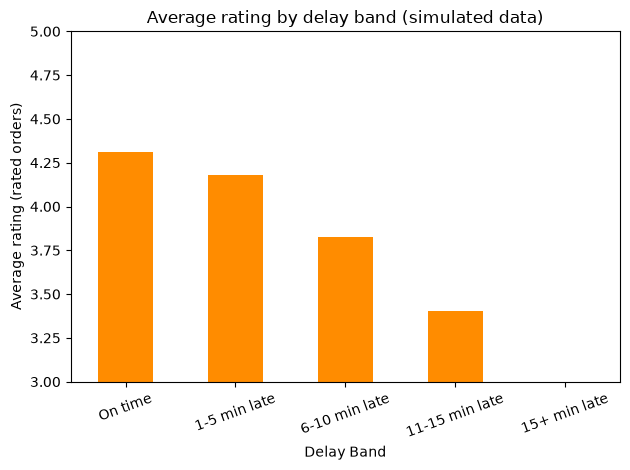

In [35]:
delay["avg_rating"].plot(kind="bar",color="darkorange")
plt.title("Average rating by delay band (simulated data)")
plt.ylabel("Average rating (rated orders)")
plt.xticks(rotation=20)
plt.ylim(3, 5)
plt.tight_layout()
plt.savefig("../visuals/rating_by_delay.png", dpi=150)
plt.show()

In [36]:
df["Severe"] = (df["Delivery Delay (Minutes)"] > 10).astype(int)
sev = df.groupby("Platform")["Severe"].mean() * 100
print(round(df["Severe"].mean() * 100, 2), "% of all orders are severely late")
sev.round(2)

2.56 % of all orders are severely late


Platform
Blinkit             2.97
JioMart             1.65
Swiggy Instamart    2.57
Name: Severe, dtype: float64

In [42]:

df["Customer Feedback"].value_counts()


Customer Feedback
No Comments                               54545
Easy to order, loved it!                   3357
Fresh stuff, will order again              3321
Quick and reliable                         3319
All good, thanks                           3317
Great packaging                            3317
Super quick!                               3313
Good quality products.                     3306
Arrived earlier than expected              3282
Smooth experience                          3245
Fast delivery, great service!              3229
Very late delivery, not happy.              855
Order took way longer than promised         801
Delivery was very slow                      799
Late again, disappointing                   789
Wrong item delivered.                       788
Got a different product than I ordered      759
Items missing from order.                   755
Half my order didn't come                   745
One item was missing                        676
Decent                

In [43]:
groups = {
    "Positive / neutral": ["Fast delivery, great service!", "Quick and reliable", "Arrived earlier than expected",
        "Good quality products.", "Easy to order, loved it!", "Smooth experience", "All good, thanks",
        "Fresh stuff, will order again", "Great packaging", "Super quick!",
        "Okay experience", "Average, nothing special", "Delivery was fine", "Decent"],
    "Late delivery": ["Very late delivery, not happy.", "Order took way longer than promised",
        "Delivery was very slow", "Late again, disappointing"],
    "Freshness": ["Not fresh, disappointed.", "Vegetables were stale", "Milk was close to expiry"],
    "Wrong item": ["Wrong item delivered.", "Got a different product than I ordered"],
    "Missing item": ["Items missing from order.", "One item was missing", "Half my order didn't come"],
    "Packaging": ["Packaging could be better.", "Box was damaged", "Items were leaking"],
    "Rider behavior": ["Delivery person was rude.", "Rider behaved badly"],
    "No Comments": ["No Comments"],
}
lookup = {text: label for label, texts in groups.items() for text in texts}
df["Feedback Type"] = df["Customer Feedback"].map(lookup)
print("Unmapped:", df["Feedback Type"].isna().sum())

Unmapped: 0


In [44]:
fb = df[df["Feedback Type"] != "No Comments"]
summary = fb.groupby("Feedback Type").agg(
    orders=("Order ID", "count"),
    avg_rating=("Service Rating", "mean"),
    refund_rate=("Refund", "mean"),
)
summary["refund_rate"] *= 100
summary["share_of_comments_%"] = summary["orders"] / len(fb) * 100
summary.sort_values("orders", ascending=False).round(1)

,orders,avg_rating,refund_rate,share_of_comments_%
Feedback Type,,,,
Positive / neutral,35248,4.4,1.2,77.7
Late delivery,3244,3.0,4.1,7.1
Missing item,2176,2.6,50.6,4.8
Freshness,1625,2.4,41.3,3.6
Wrong item,1547,2.4,47.6,3.4
Packaging,1028,3.5,8.2,2.3
Rider behavior,523,2.9,1.7,1.2


In [45]:
ct = pd.crosstab(df["Product Category"], df["Feedback Type"], normalize="index") * 100
ct[["Freshness", "Wrong item", "Missing item", "Late delivery"]].round(1)

Feedback Type,Freshness,Wrong item,Missing item,Late delivery
Product Category,,,,
Beverages,0.6,1.5,2.2,3.4
Dairy,2.6,1.7,2.2,3.1
Fruits & Vegetables,4.1,1.5,2.1,2.9
Grocery,0.6,1.6,2.3,3.3
Personal Care,0.6,1.4,2.2,3.3
Snacks,0.5,1.6,2.0,3.6
